**Übersicht**

StudentenName: xxx

Matrikel: xxx

Datum: xxx

Version: xxx


## Pflichtabgabe 02 - Bioreaktorkinetik ##
<hr>

Die Modellierung von Bioreaktoren hilft Biotechnolog:Innen bei der Wahl eines korrekten Produktionssystems für ihr gewünschtes Produkt. Durch immer komplexere Modelle erhofft man sich immer exaktere Vorhersagen und somit weniger Experimentieraufwand. Das Grundprinzip soll an einem sehr einfachen Beispiel eines Batch-Prozesses verdeutlicht werden, bevor ein CSTR nach gleichen Prinzip modelliert werden soll.

Zur Modellierung eines Reaktors muss zuerst dessen Bilanz aufgestellt werden. Erinnerung: Es gilt die allgemeine Bilanzgleichung für einen Bioprozess:

$ \frac{dVY}{dt}=V\sum r_{Bildung}-V\sum r_{Abbau}+F_iY_i-\gamma F_oY_o $

Mit Y für die einzelnen Prozessgrößen (X, S, P, ...). Da es sich um einen Batchprozess handelt, sind einige Annahmen zu machen:
<br><br> **1. Reaktorvolumen ist konstant
<br> 2. kein Ein- oder Ausfluss
<br> 3. Substrat wird abgebaut, Produkt und Biomasse werden aufgebaut**
<br><br> Für Biomasse, Produkt und Substrat gelten dann:
<br><br> $ \frac{dX}{dt}=(µ-k_d)X $
<br><br> $ \frac{dX}{t}=-\frac{µX}{Y'_{X /S}}-\frac{\alpha µX}{Y'_{P /S}} $
<br><br> $ \frac{dX}{dt}=\alpha µX $
<br><br>
Ein Batch-Reaktor ist ein geschlossenes System, in dem sich die Prozessgrößen X, S und P gegenseitig beeinflussen. Mit der Bilanzierung für die einzelnen Größen kann nun ein Differenzialgleichungssystem aufgestellt werden, dessen Lösung die Konzentrationen zu jedem beliebigen Zeitpunkt ausgibt. Die Python-Library "SciPy" erledigt hier den Großteil der Arbeit, sodass wir nur unsere Formeln korrekt aufstellen und nach unten stehender Syntax eingeben müssen.
<br><br>
Die zu bearbeitenden Aufgaben finden Sie unter dem folgenden Beispiel.

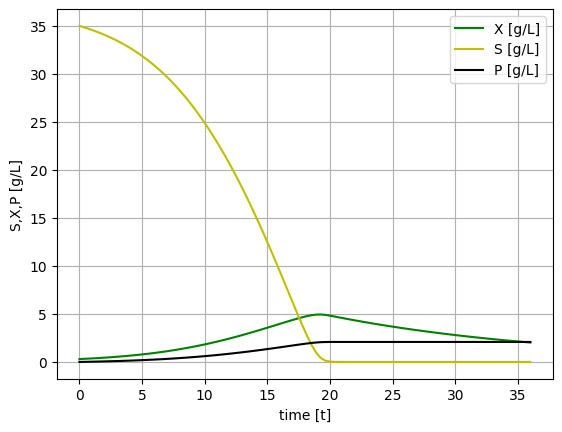

In [2]:
##########################################

# Uebung 4 - Bioreaktorkinetik
# 07.12.2023
# Version 1.2

#########################################

# Falls ihr scipy nicht installiert habt, könnt ihr
# dies mit folgendem Befehl tun

#!pip install scipy

#########################################
# 1. Import der Module
from matplotlib import pyplot as plt
    # Das Modul zum plotten
import numpy as np
    # Benutzen wir für das erstellen unserer X-Achse
from scipy.integrate import solve_ivp
    # der Solver  
    
#########################################
# 2. Initialisierung der Konstanten:
spez_Produktivität          = alpha = 0.3     # gP/gX
max_spez_Wachstumsrate      = µmax  = 0.26    # /h
Inhibitionskonstante        = KI    = 3       # g/L
Halbsaettigungskonstante    = KS    = 1       # g/L
Sterberate                  = kd    = 0.0545  # /h
Prozessdauer                = tmax  = 36      # h
spez_Ausbeutefaktor_X       = YXS   = 0.26    #gx/gs
spez_Ausbeutefaktor_P       = YPS   = 0.25    #gp/gs

########################################

# 3. Definition des DGL-Systems 
# Definieren eines Vektors, der all unsere Konstanten beinhält:
# Vektor "F", der sich über die Zeit verändert. Der Vektor beinhält das DGL-System,
# welches in unserem Fall aus drei Komponenten besteht: X, S und P
def dFdt(t,F):
    # Die Variablen X, S und P entsprechen der jeweiligen Funktion des Vektors F.
    X,S,P = F
    return [
            # Listen der für X, S und P korrespondierenden Gleichungen. Wichtig: gleiche Reihenfolge wie
            # zuvor! (X, S, P)
            
            #Biomassegleichung
            (µmax * S / (S + KS) * KI / (P + KI) - kd) * X ,
            #Substratgleichung
            - µmax * S / (S + KS) * KI / (P + KI) * X / YXS - alpha * µmax * S / (S + KS) * KI / (P + KI) * X / YPS ,
            #Produktgleichung
            alpha * µmax * S / (S + KS) * KI / (P + KI) * X
            ]
# Beachte: Der Teil, der in den eckigen Klammern steht, steht rechts vom Gleichzeichen zum korrespondierenden Parameter
# Wird das DGL system mit Daten gefüttert, wird der Vektor F = X,S,P zu einer Matrix erweitert.
# Anstelle der Variablen X,S,P werden die Daten in Listenform in den Vektor gespeichert, ihm wird eine Dimension hinzugefügt. 

########################################

# 4. Angabe der Startwerte

# Die Anfangsbedingungen sind hier willkürlich gewählt. Eine Anfangskonzentration
# der Biomasse ist notwendig, außerdem liegt das Substrat bereits vor.
X = 0.3 # [g/L]
S = 35  # [g/L]
P = 0   # [g/L]

F_0 = (X,S,P)

#######################################

# 5. x-Achse initiieren, Gleichung lösen und y-Werte extrahieren
# Unseren Fermentationszeitraum definieren.

t = np.linspace(0,tmax,100)
    # Hier: np.linspace (Start, Ende, Anzahl der Schritte)


sol = solve_ivp(dFdt, t_span=(0,max(t)),y0=F_0, method="RK45", t_eval=t)

# solve_ivp wurde zuvor importiert.
    # WICHTIG: Syntax wie oben vollständig übernehmen (bsp: )
                         # Richtig: sol = solve_ivp(dFdt, t_span=(0,max(t)),y0=F_0, method="RK45", t_eval=t)
                         # Falsch:  sol = solve_ivp(dFdt, (0,max(t)), F_0,"RK45", t)
    # 1. Parameter: unsere Funktion (hier dFdt)
    # 2. Parameter: unsere Funktionsspanne (hier von 0 bis t(max))
    # 3. Parameter: unser Anfangswert Vektor (hier F_0)
    # 4. Parameter: der Lösungsalgorithmus. Optional. Nimmt Standardalgorithmus wenn leer gelassen
    # 5. Parameter: evaluierungsintervall (hier t)

    
#    Werte ausgeben lassen. print(sol) gibt ein Ergebnisfenster aus, das wir nicht plotten können.
#    Stattdessen geben wir die Werte X, S, P mit der .y[i] funktion aus. Hier gilt wieder die Reihen-
#    folge zu beachten. X wurde als erstes eingeführt, weshalb es den index 0 hat. Usw.
X_sol = sol.y[0]
S_sol = sol.y[1]
P_sol = sol.y[2]

#########################################

# 6. Ergebniss plotten
#    Die Daten können nun standardmäßig gegen die Zeit geplottet werden.

plt.plot(t,X_sol, label="X [g/L]", color="g")
plt.plot(t,S_sol, label="S [g/L]", color="y")
plt.plot(t,P_sol, label="P [g/L]", color = "k")


plt.xlabel("time [t]")
plt.ylabel("S,X,P [g/L]")
plt.grid()
plt.legend()
plt.show()

#########################################

Beantworten Sie die Aufgaben in der unten stehenden Antwortzelle. Die Formeln können Sie alternativ auch auf Papier schreiben und ein Foto davon schicken.
<br><br>
**Aufgabe 1:** Leite aus der allgemeinen Form nun die Bilanzgleichung für Fed-Batch und kontinuierliche Reaktoren her. Welche Annahmen müssen getroffen werden, um die allgemeine Form der Bilanzgleichung zu vereinfachen?
<br><br>
**Aufgabe 2:** Stelle die vereinfachte Bilanzgleichung für einen der beiden Kultivierungstypen für die folgenden Zustandsgrößen auf: lebende Zellen, Substrat und Produkt
<br><br>
**Aufgabe 3:** Simuliere einen Fedbatch und einen CSTR Prozess mit den folgenden Parametern. Inhibitionen und Zellsterberate sind zu vernachlässigen.: <br><br>
**CSTR**
|Symbol|Bezeichnung|Wert|
|-|-|-|
|$\alpha$|spez. Produktivität| $0.6 g_Pg_X^{-1}$ |
|$µ_{max}$|Wachstumsrate| $ 0.5 h^{-1}$|
|$K_s$|Halbsättigungskonstante| $ 0.9 gL^{-1}$|
|$Y'_{X/S}$|spez. Ausbeutefaktor|$0.6 g_Xg_S^{-1}$|
|$Y'_{P/S}$|spez. Ausbeutefaktor|$0.6 g_Pg_S^{-1}$|
|$ t_{max}$|Prozessdauer|$48.0h$|
|$ S_{i}$|Zuflusskonzentration|$5gL^{-1}$|
|$ D $ bzw. $ Vr $|Verdünnung bzw. Volumenstrom|$0.2h^{-1} $bzw. $0.2 L/h^{-1}$|




Die Startbedingungen lauten:
<br><br>
X (t=0) = 0.1 &emsp; S (t=0) = 5 g/L, &emsp; P (t=0) = 0 g/L &emsp; Für Fedbatch: V (t=0) = 20 L

## Antworten ##
<hr>

Fed-batch: Keine Substratgeneration. Kein Einstrom für Biomasse und Produkt. Beachte: Volumenänderung! Eventuelle Biomassedegeneration (sterberate)
CSTR: Keine Substratgeneration. Keine Volumenveränderung, kein Einstrom für Biomasse und Produkt. Eventuelle Biomassedegeneration (sterberate)

### Fedbatch

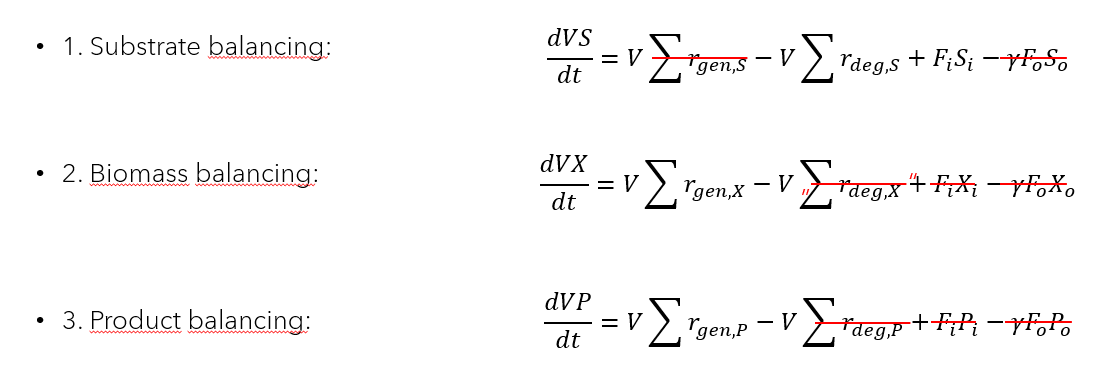

## CSTR

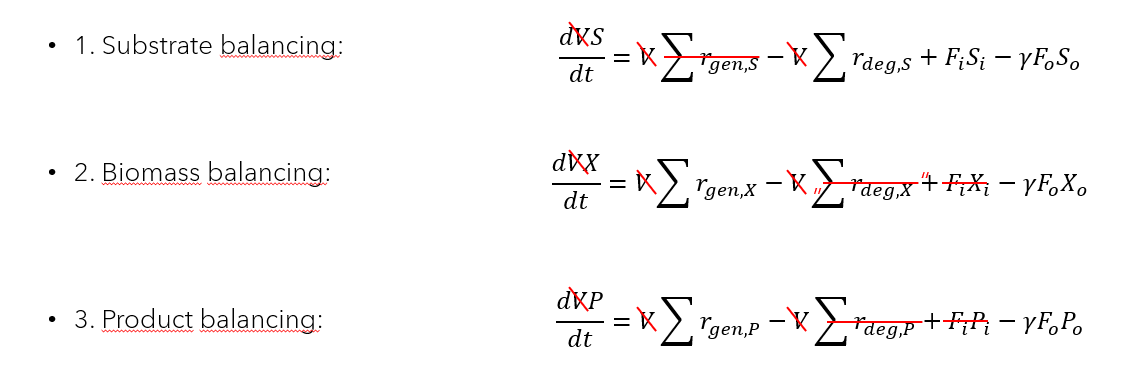

**Aufgabe 3:** Simuliere einen Fedbatch und einen CSTR Prozess mit den folgenden Parametern. Inhibitionen und Zellsterberate sind zu vernachlässigen.: <br><br>
**CSTR**
|Symbol|Bezeichnung|Wert|
|-|-|-|
|$\alpha$|spez. Produktivität| $0.6 g_Pg_X^{-1}$ |
|$µ_{max}$|Wachstumsrate| $ 0.5 h^{-1}$|
|$K_s$|Halbsättigungskonstante| $ 0.9 gL^{-1}$|
|$Y'_{X/S}$|spez. Ausbeutefaktor|$0.6 g_Xg_S^{-1}$|
|$Y'_{P/S}$|spez. Ausbeutefaktor|$0.6 g_Pg_S^{-1}$|
|$ t_{max}$|Prozessdauer|$48.0h$|
|$ S_{i}$|Zuflusskonzentration|$5gL^{-1}$|
|$ D $ bzw. $ Vr $|Verdünnung bzw. Volumenstrom|$0.2h^{-1} $bzw. $0.2 L/h^{-1}$|




Die Startbedingungen lauten:
<br><br>
X (t=0) = 0.1 &emsp; S (t=0) = 5 g/L, &emsp; P (t=0) = 0 g/L &emsp; Für Fedbatch: V (t=0) = 20 L

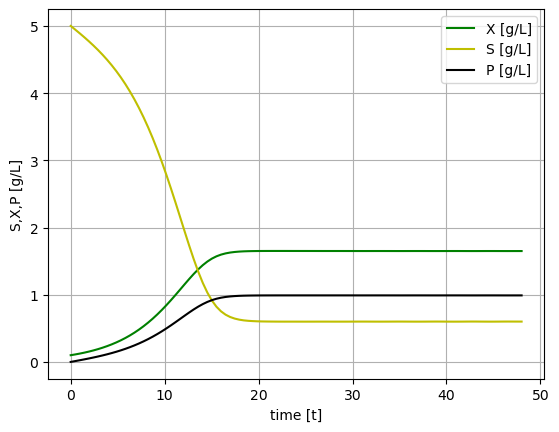

In [2]:
##########################################

# Uebung 4 - Bioreaktorkinetik
# 07.12.2023
# Version 1.2

#########################################

# 1. Import der Module
from matplotlib import pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

# 2. Initialisierung der Konstanten

spez_Produktivität          = alpha = 0.6
max_spez_Wachstumsrate      = µmax  = 0.5
Halbsaettigungskonstante    = KS    = 0.9
Substratzuflusskonzentration= Si    = 5
spez_Ausbeutefaktor_X       = YXS   = 0.6
spez_Ausbeutefaktor_P       = YPS   = 0.6
Verdünnungsrate_D           = D     = 0.2
tmax                        = time  = 48
Erhaltungsstoffwechsel      =  mS   = 0

# 3. Definieren des DGL-Systems

def dFdt(t,F):
    X,S,P = F
    return [
            #Biomassegleichung
            (µmax*S/(S+KS)) * X - D * X,
            #Substratgleichung
            -(µmax*S/(S+KS)/YXS+mS)*X-alpha*µmax*S/(S+KS)*X/YPS + D*(Si-S)
            ,
            #Produktgleichung
            alpha * µmax * S / (S + KS) * X - D*P
            ]

# 4. Angabe der Startwerte, Erstellung eines Startwert-Vektors

X = 0.1
S = 5
P = 0

F_0 = (X,S,P)

# 5. X-Achse initialisieren, Gleichung lösen und Werte extrahieren

t = np.linspace(0,tmax,100)

    # Lösen der Gleichung
sol = solve_ivp(dFdt, t_span=(0,max(t)),y0=[X,S,P], method="RK45", t_eval=t)

    # Extraktion der Daten
X_sol = sol.y[0]
S_sol = sol.y[1]
P_sol = sol.y[2]

# 6. Ergebnisse plotten

    # Daten plotten
plt.plot(t,X_sol, label="X [g/L]", color="g")
plt.plot(t,S_sol, label="S [g/L]", color="y")
plt.plot(t,P_sol, label="P [g/L]", color = "k")

    # Modifikation des Graphen
plt.grid()
plt.legend()
plt.xlabel("time [t]")
plt.ylabel("S,X,P [g/L]")
plt.show()

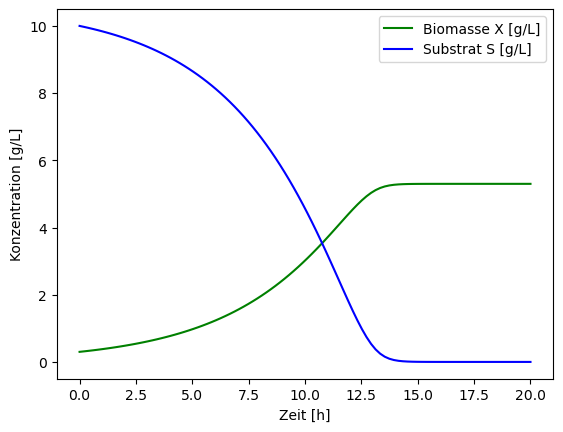

SyntaxError: expression cannot contain assignment, perhaps you meant "=="? (532801829.py, line 28)